# Trying out training with a very unsophisticated model 
## Speed-optimized version

In [1]:
# import pytorch
import torch

import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.transforms import ToTensor, Lambda
from torch.optim.lr_scheduler import StepLR

import matplotlib.pyplot as plt
import numpy as np

# custom code
import source.preprocessing as cheepre
import mypytorch.mymodels as mm
import mypytorch.dataset_classes as md
import mypytorch.mytrainer as mt

In [15]:
import importlib; importlib.reload(cheepre); importlib.reload(mm); importlib.reload(md); importlib.reload(mt); 

In [ ]:
%%capture
ANNOT_DIR = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_humanannotated/'
IMG_DIR   = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_grey/'
mydataset = md.CustomImageDataset(annot_dir=ANNOT_DIR, 
                               img_dir=IMG_DIR, 
                               transform=ToTensor(), 
                               target_transform=Lambda(lambda y: torch.zeros(6, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)), 
                               preload_imgs=True)
                               

Dataset size:  494732


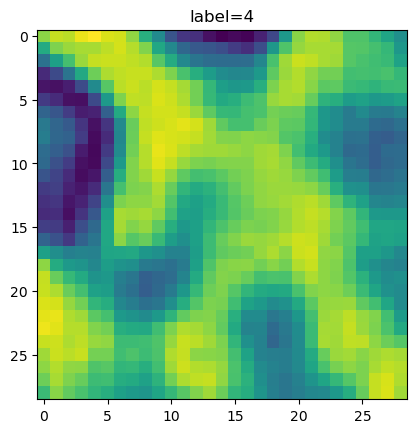

In [6]:
# show one of the images of "mydataset" above
image, label = mydataset[0]
plt.imshow(image.to("cpu")[0])
plt.title('label='+str(np.where(label.to("cpu"))[0][0]))
# also show size of "mydataset"
print('Dataset size: ', len(mydataset))

In [7]:
# show size of "mydataset"
len(mydataset)

494732

In [8]:
# divide mydataset into 20% test set and 80% training set

from torch.utils.data import random_split

# Define the sizes of your splits
total_size = len(mydataset)
train_size = int(0.8 * total_size)  # 80% for training
val_size = total_size - train_size   # 20% for validation

# Create the splits
train_dataset, val_dataset = random_split(
    mydataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # For reproducibility
)

In [9]:
# Device a weighing scheme, that can be used for evenly distributed sampling
# get label distributions
# horribly slow:
#labels_trainset = [train_dataset[i][1] for i in range(len(train_dataset))] 
#labels_valset   = [val_dataset[i][1] for i in range(len(val_dataset))]
# faster:
original_labels = mydataset.labels
labels_trainset    = original_labels[train_dataset.indices]
labels_valset      = original_labels[val_dataset.indices]

# weights for training set
train_bincounts = np.bincount(labels_trainset)
class_weights_train = 1.0 / train_bincounts
class_weights_train[train_bincounts==0] = 0 # counters div 0
weights_train = class_weights_train[labels_trainset]  # Assign a weight to each sample
# also for val_set
val_bincounts = np.bincount(labels_valset)
class_weights_val = 1.0 / val_bincounts
class_weights_val[val_bincounts==0] = 0
weights_val = class_weights_val[labels_valset]  # Assign a weight to each sample
# set samplers
sampler_train = WeightedRandomSampler(weights_train, num_samples=len(train_dataset), replacement=True)
sampler_val   = WeightedRandomSampler(weights_val, num_samples=len(val_dataset), replacement=True)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, 
                        sampler=sampler_train) # untested

generator = torch.Generator().manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=64, # shuffle=False, 
                        shuffle=False, generator=generator, # untested
                        sampler=sampler_val)

/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_58580/363099376.py:13: RuntimeWarning: divide by zero encountered in divide
  class_weights_train = 1.0 / train_bincounts
/var/folders/8w/2thz_cgn3xn13rhrxb2dvb5w0000gn/T/ipykernel_58580/363099376.py:18: RuntimeWarning: divide by zero encountered in divide
  class_weights_val = 1.0 / val_bincounts


In [10]:
print(class_weights_val)
print(class_weights_train)

[0.00000000e+00 3.04451075e-05 3.16105579e-05 1.39918847e-04
 4.12609341e-05 3.24359390e-04]
[0.00000000e+00 7.58109880e-06 8.03051596e-06 3.47222222e-05
 1.01876566e-05 8.06776926e-05]


In [11]:
type(labels_trainset)

numpy.ndarray

In [289]:
# mydataset[1]

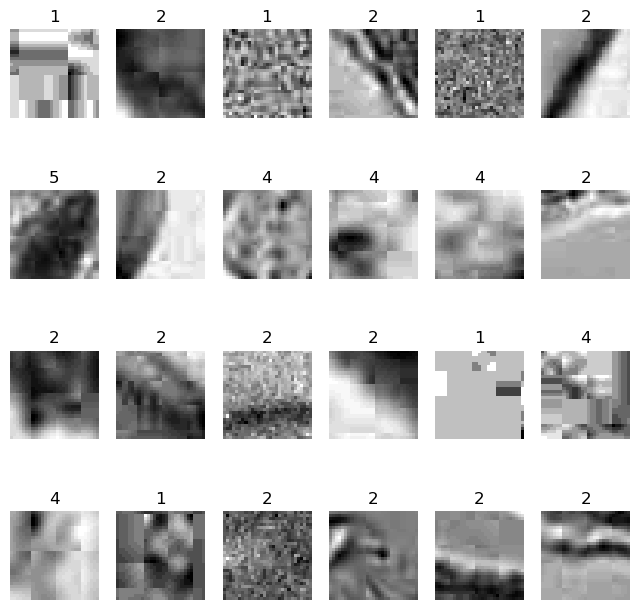

shape img torch.Size([1, 29, 29])


In [17]:
# Show images from the train_dsatset with labels
# train_dataset, val_dataset 

figure = plt.figure(figsize=(8, 8))
cols, rows = 6, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    img, label = img.to("cpu"), label.to("cpu")
    # convert label to default python int
    label_det = str(label.argmax().detach().cpu().numpy())
    figure.add_subplot(rows, cols, i)
    plt.title(   label_det   )
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

print('shape img', img.shape)
# ({int(label.detach().cpu().numpy())})


# Now define the model (simple one from tutorial)

In [18]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# get training device
device = "mps" if torch.backends.mps.is_available() else "cpu" # code is different from tutorial (fixed with co-pilot)
print(f"Using {device} device")

Using mps device


In [ ]:
# move model to the correct device
model = mm.VerySimpleNN().to(device)
print(model)

VerySimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=841, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=6, bias=True)
  )
)


In [ ]:
# We can now already call the model

X = torch.rand(1, 1, 29, 29, device=device) # random image as test input 
logits = model(X) # "logits" refers to raw, unnormalized outputs of the final layer of a neural network
print('shape',logits.shape)
#pred_probab = nn.Softmax(dim=1)(logits) # converts output layer to probabilities
#print(f'Probabilities: {pred_probab}')
#y_pred = pred_probab.argmax(1) # finds the most likely label
#print(f"Predicted class: {y_pred}")

shape torch.Size([1, 6])


# Now train the model

In [22]:
# Hyperparameters

# Hyperparameters are not parameters that define the model, but parameters that 
# relate to finding the solution;
    # - numbers of epochs: number of times to iterate over the whole dataset
    # - batch size: (PB) typically the loss of multiple instances is calculated in 
    #   paralellel; the loss is then determined as L(L1, L2, L3, L_batchsize), typically just
    #   sum. The backward propagation needs to be called from a single scalar
    #   tensor; So you simply define L = L1 + L2 + L3 + L_batchsize, the tensor 
    #   concept allows then backpropagation on L, implicitly taking all L_i into
    #   account.
    # - learning rate: how much to update models parameters at each batch/epoc;
        # I'm guessing this is some factor sets the size of W updates.

learning_rate = 1e-1 # 1e-3
batch_size = 64
epochs = 5

# We need to set loss function, and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    # optimizer will actually implement some form of gradient descent

In [ ]:
# The training loop is custom coded

TOTAL_SAMPLES     = int(100_000)
TOTAL_TESTSAMPLES = int(10_000)
NUM_TESTBATCHES = int(np.ceil(TOTAL_TESTSAMPLES/64))

def train_loop(dataloader, model, loss_fn, optimizer):
    
    size = len(dataloader.dataset)
    loss_tracker = []
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            loss_tracker.append(loss)
            #print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            print(f"loss: {loss:>7f}  [{current:>5d}/{TOTAL_SAMPLES:>5d}]")
            
        if (batch * batch_size + len(X)) > TOTAL_SAMPLES: # 100_000:
            print('Epoch done')
            break
        
    return loss_tracker
            
def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = NUM_TESTBATCHES*64 # len(dataloader.dataset)
    num_batches = NUM_TESTBATCHES # len(dataloader)
    test_loss, correct = 0, 0
    
    print('Predicting for test set.')
    
    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for batch_idx, (X, y) in enumerate(dataloader):            
            
            if batch_idx>num_batches:
                break
            if batch_idx % 25 == 0:
                print(f'Batch {batch_idx}')
            
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            # correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            correct += (y.argmax(1) == pred.argmax(1)).type(torch.float).sum().item()        

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    return correct

In [ ]:
# Now actually execute the training

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)

epochs = 30
list_loss_tracker = []
list_correct = []
for t in range(epochs):
    
    print(f"Epoch {t+1}, LR: {scheduler.get_last_lr()}")
    
    # train and test
    loss_tracker = train_loop(train_loader, model, loss_fn, optimizer)
    current_correct  = test_loop(val_loader, model, loss_fn)
    
    # update scheduler
    scheduler.step()
    
    # track loss & test correctness
    list_loss_tracker.append(loss_tracker)    
    list_correct.append(current_correct)
print("Done!")

# estimated training time:
# 25664 samples = 1:40 = 100 s
# ±40x as long --> 4000 seconds --> ±1hr 6min

Epoch 1, LR: [0.1]
loss: 1.788101  [   64/100000]
loss: 1.565254  [ 6464/100000]
loss: 1.611518  [12864/100000]
loss: 1.804005  [19264/100000]
loss: 1.400794  [25664/100000]
loss: 1.309637  [32064/100000]
loss: 1.365159  [38464/100000]
loss: 1.200854  [44864/100000]
loss: 1.345197  [51264/100000]
loss: 1.486612  [57664/100000]
loss: 1.783285  [64064/100000]
loss: 1.276395  [70464/100000]
loss: 1.250120  [76864/100000]
loss: 1.262405  [83264/100000]
loss: 1.392389  [89664/100000]
loss: 1.244125  [96064/100000]
Epoch done
Predicting for test set.
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Batch 80
Batch 90
Batch 100
Batch 110
Batch 120
Batch 130
Batch 140
Batch 150
Test Error: 
 Accuracy: 41.7%, Avg loss: 1.299618 

Epoch 2, LR: [0.1]
loss: 1.380288  [   64/100000]
loss: 1.323584  [ 6464/100000]
loss: 1.274522  [12864/100000]
loss: 1.295749  [19264/100000]
loss: 1.351502  [25664/100000]
loss: 1.666451  [32064/100000]
loss: 1.150170  [38464/100000]
loss: 1.2881

In [ ]:
# Now save the model and its weights
# generate current date
import datetime
current_date = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
PATH = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/pytorchmodel_'+current_date+'.pth'
torch.save(model.state_dict(), PATH)

In [1]:
# import datetime
# datetime.datetime.now()
# .strftime("%Y-%m-%d_%H:%M")

print('test')

test


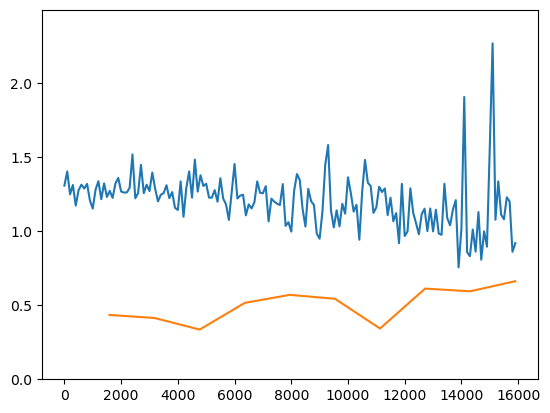

In [ ]:
# Plot list_loss_tracker

import matplotlib.pyplot as plt
import numpy as np

datay = np.array(list_loss_tracker).flatten()
datax = np.array(range(len(datay)))*100
plt.plot(datax, datay)
plt.ylim([0, np.max(datay)*1.1])
datax[-1]

# and also plot the list_correct
data_correctx = np.linspace(datax[-1]/10, datax[-1], 10)
data_correcty = np.array(list_correct)
plt.plot(data_correctx, data_correcty)


In [ ]:
len()

160